In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Imports

In [2]:
from pathlib import Path
import pandas as pd

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import plot_in_rectangular_coordinates, PlotManager
from src.models.logistic_regression import train_logistic_regression
from src.visualization.decision_boundaries import plot_decision_boundary
from src.evaluation.metrics import ModelMetrics
from src.features.transformations import cartesian_to_polar, cartesian_to_elliptic

-----------------------

# Data Exploration

## Data Loading

In [3]:
current_dir = Path.cwd()

# Load the dataset
data_path = current_dir.parent / "data" / "raw" / "points.json"
dataset = PointsDataset.from_json(data_path=data_path)

In [4]:
# Print essential statistics
print('- Number of positive points:', len(dataset.y[dataset.y==1]))
print('- Number of negative points:', len(dataset.y[dataset.y==0]))
print('- Total number of points:', len(dataset.y[dataset.y==1]) + len(dataset.y[dataset.y==0]))

# Preview dataframe
print('- Predictors shape:', dataset.X.shape, 'Predictions shape:', dataset.y.shape)

# Data as single dataframe
df = pd.concat([dataset.X, dataset.y], axis=1)
print('\n- Dataframe info:')
print(df.info())
print('\n- Dataframe preview:')
print(df.head())
print('\n- Dataframe describe:')
print(df.describe())

- Number of positive points: 50
- Number of negative points: 49
- Total number of points: 99
- Predictors shape: (99, 2) Predictions shape: (99,)

- Dataframe info:
<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      99 non-null     float64
 1   x2      99 non-null     float64
 2   label   99 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.4 KB
None

- Dataframe preview:
         x1        x2  label
0 -1.173217  0.870813      0
1  0.754003  0.392344      1
2  0.375546  1.665072      0
3 -0.381368 -0.803828      1
4  0.666667  1.894737      0

- Dataframe describe:
              x1         x2      label
count  99.000000  99.000000  99.000000
mean    0.014791  -0.012566   0.505051
std     1.003884   1.003415   0.502519
min    -1.924309  -2.153110   0.000000
25%    -0.733624  -0.822967   0.000000
50%    -0.020378  -0.019139   1.000000
75%     0.75

Distribution of values suggesting plotting should be safe, simple and visually informative.

## Plotting

In [5]:
PLOT_CONFIG = {
    "show": True,
    "save": True,
    "out_dir": current_dir.parent / "results" / "figures"
}

plot_manager = PlotManager(PLOT_CONFIG)

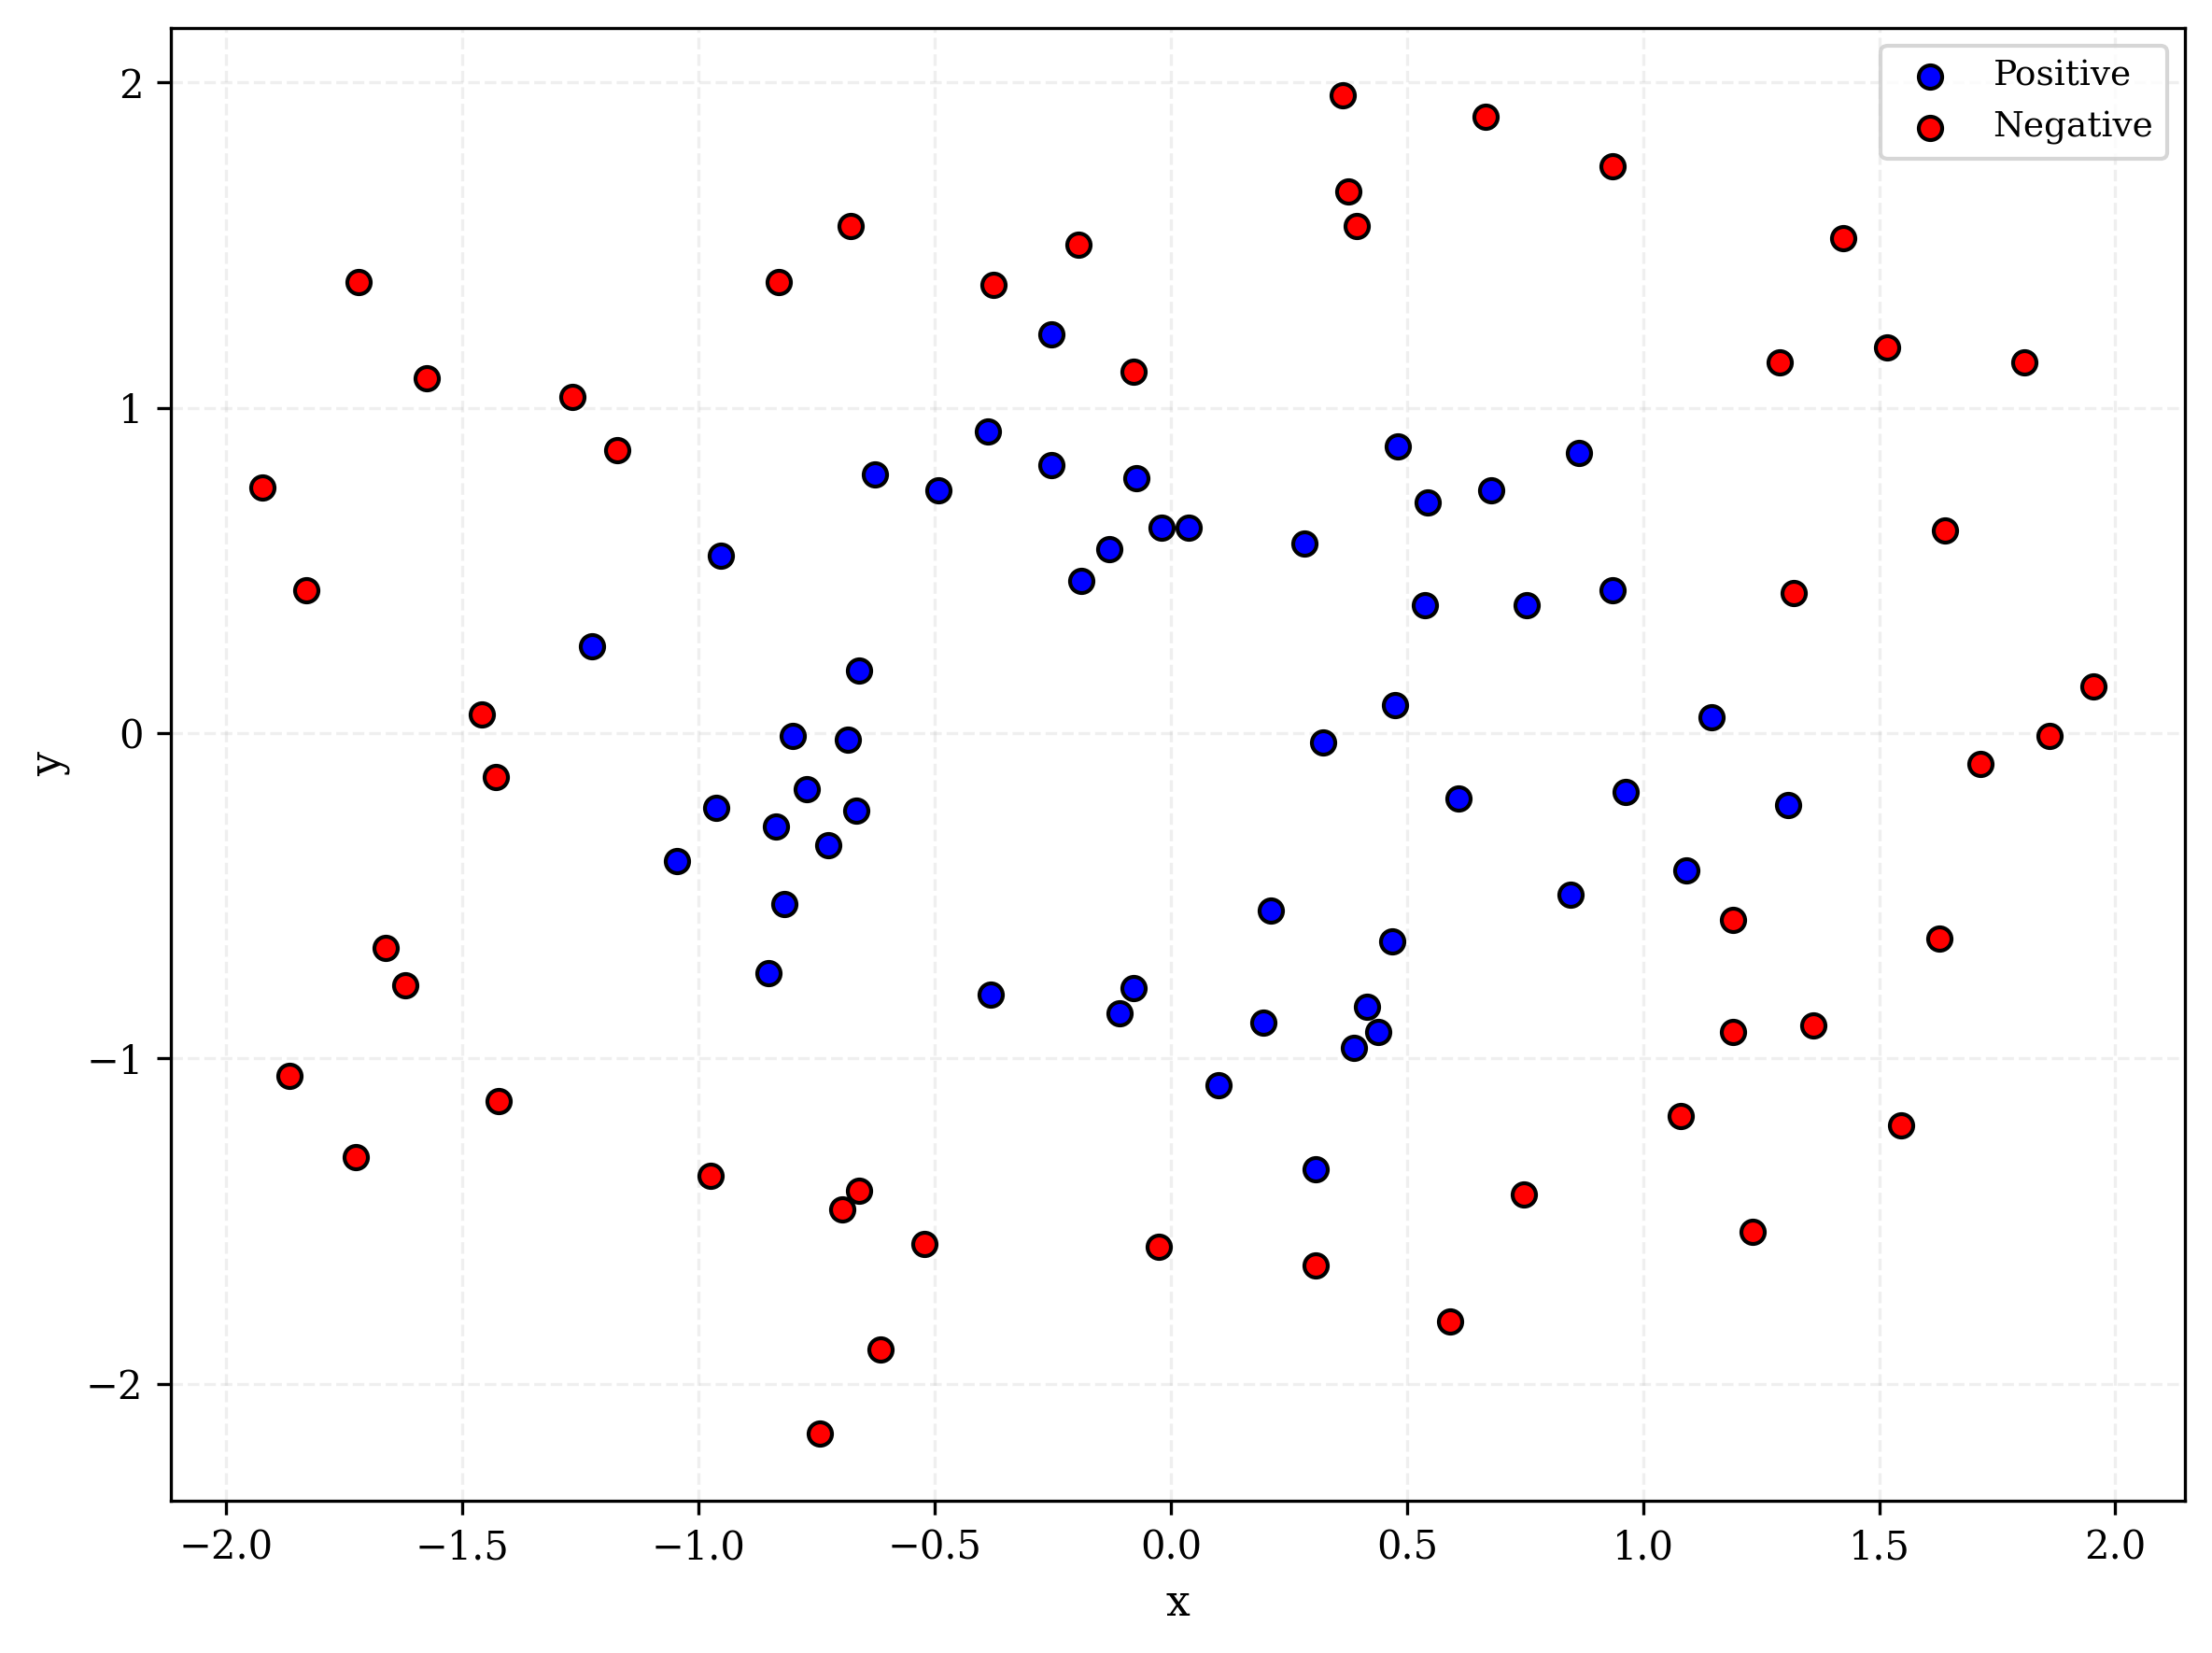

In [9]:
raw_data_fig, raw_data_ax = plot_in_rectangular_coordinates(dataset.X, dataset.y, title='', axis_x_label='x', axis_y_label='y')
display(raw_data_fig)

In [10]:
plot_manager.handle(raw_data_fig, name='original_dataset')

## Initial Data Observations

- There are 99 points, split virtually even among the two classes.
    - Data size is relatively small.
- Data does not seem sparse.
- A standard linear classifier will likely fail in the Cartesian coordinate space, but the structure suggests that an appropriate transformation could simplify the problem.
    - Positive points are noticeably closer to a point than are negative ones. In this representation, that point is the origin.
    - The coordinate axes are close to being axes of symmetry for the data points, implying some degree of angular symmetry. 
- The decision boundary resembles an ellipse
    - Radial distance from the origin alone appears to be the most important relevant feature
- Radial and angular coordinates would be a more natural choice for this system
- The classification proble could be linear in polar and/or elliptical coordinates

## Prepare for Modeling

Set up Cartesian grid for decision boundary evaluation and visualization.

In [11]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(dataset.X)

-------------------------------

# Logistic Regression Attempt on Raw Data

Evaluate whether a linear model is sufficient in raw feature space.

In [12]:
lr_model = train_logistic_regression(dataset.X, dataset.y)

In [13]:
lr_metrics = ModelMetrics('Logistic Regression', 'Cartesian', dataset.y, lr_model.predict(dataset.X))
lr_metrics.compute_metrics()
lr_metrics.to_pandas()

,accuracy,precision,recall,f1
0,0.616162,0.568182,1.0,0.724638


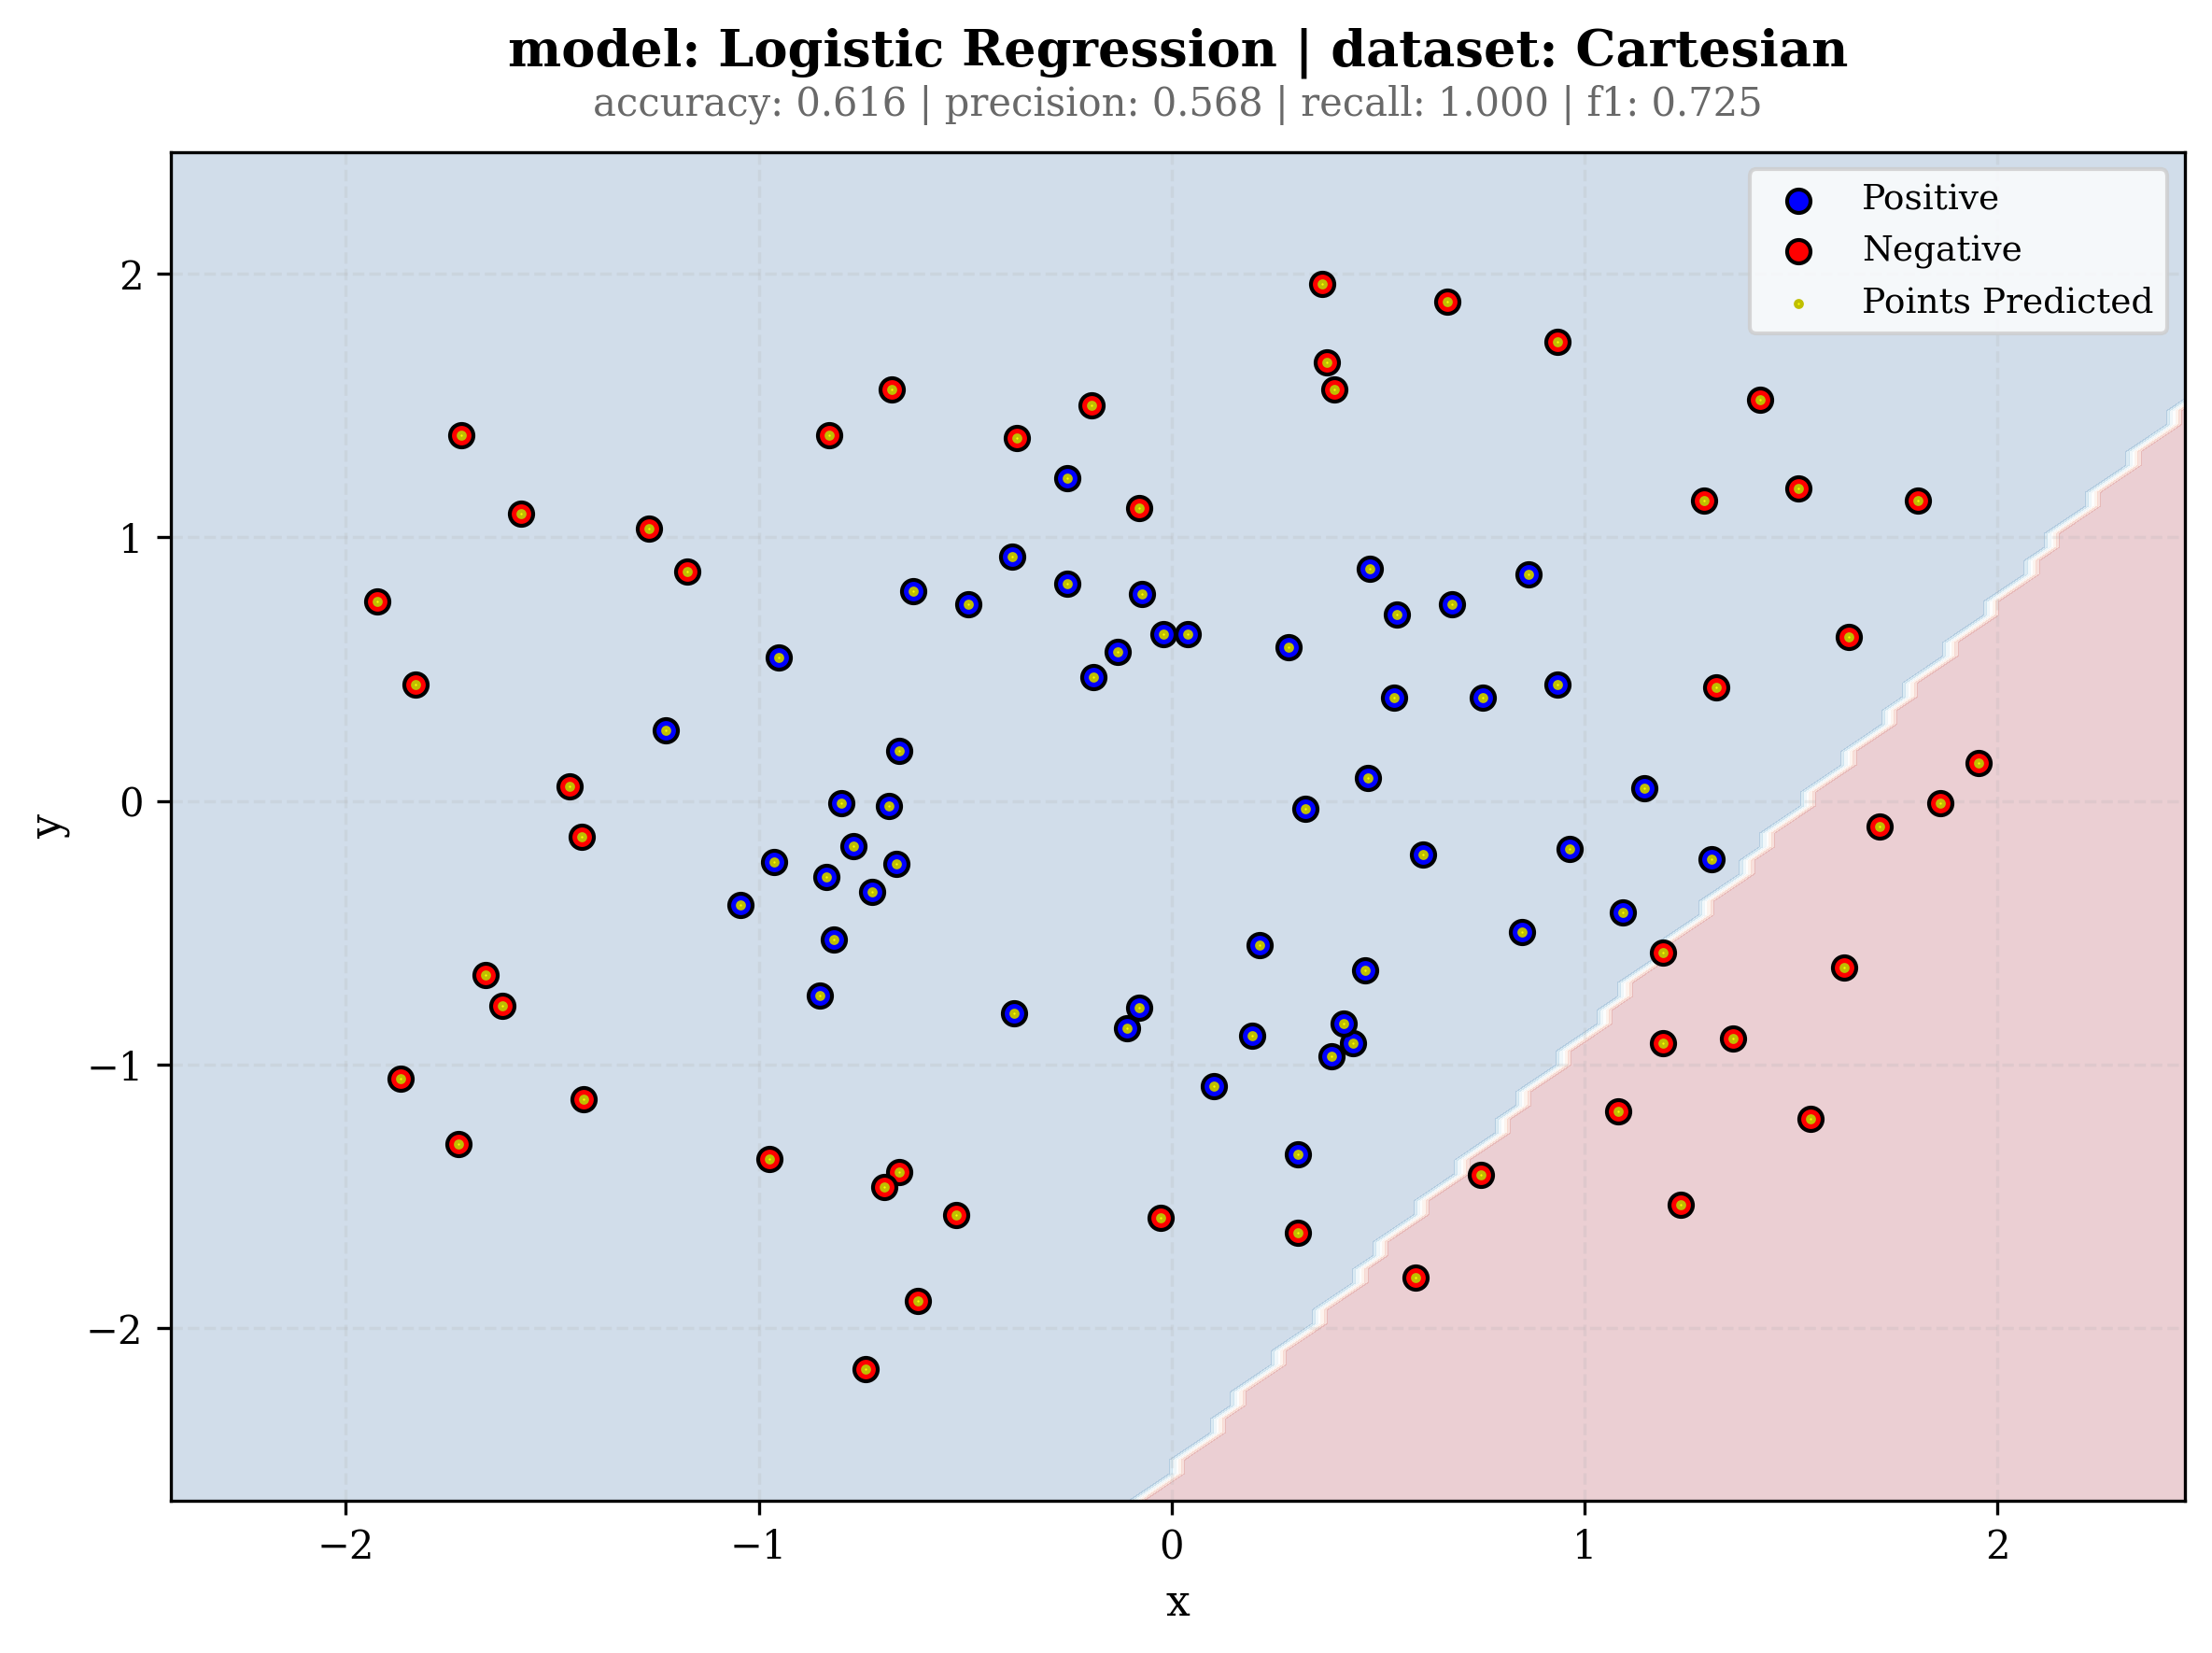

In [14]:
fig, ax = plot_decision_boundary(
    model=lr_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=f'model: {lr_metrics.metadata['model']} | dataset: {lr_metrics.metadata['dataset']}',
    metrics=lr_metrics.to_dict(),
    axis_x_label='x',
    axis_y_label='y'
)

display(fig)

In [15]:
plot_manager.handle(fig, name='logi_regr_rectangular')

Performance suggests strong non-linearity in decision boundary.